In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 12, 'axes.titleweight': 'bold',
    'axes.labelsize': 10, 'xtick.labelsize': 8.5, 'ytick.labelsize': 8.5,
    'legend.fontsize': 8.5, 'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f6', 'axes.grid': True,
    'grid.color': 'white', 'grid.linewidth': 0.8,
})

## 1 — Load & Parse Data: ClassTran Ecolane reservation and trip data

This notebook uses the Ecolane reservation/trip workbook for July 2022 through June 2023. The workbook sheet is `SMART Trip Data`. After loading, the code creates standardized address and coordinate aliases such as `pickup_address`, `dropoff_address`, `pickup_lat`, `pickup_lon`, `dropoff_lat`, and `dropoff_lon` so the downstream analysis can use the same field names throughout the notebook.


In [4]:
from pathlib import Path


DATA_PATH = Path(
    "/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/"
    "Ecolane Reservation and Trip Data July 2022 - June 2023.xlsx"
)
SHEET_NAME = "SMART Trip Data"
df_raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)


def combine_address_parts(df, street_number_col, street_col, city_col, state_col, zipcode_col):
    parts = []
    for col in [street_number_col, street_col, city_col, state_col, zipcode_col]:
        part = df[col].fillna('').astype(str).str.strip()
        part = part.str.replace(r'\.0$', '', regex=True)
        parts.append(part)
    address = parts[0] + ' ' + parts[1]
    address = address.str.strip()
    city_state_zip = parts[2] + ', ' + parts[3] + ' ' + parts[4]
    city_state_zip = city_state_zip.str.replace(r'^[,\s]+|[,\s]+$', '', regex=True)
    return (address + ', ' + city_state_zip).str.replace(r'^[,\s]+|[,\s]+$', '', regex=True)


# Standardize Ecolane column names used by later cells.
df_raw['pickup_lat'] = df_raw['Pick-up Latitude']
df_raw['pickup_lon'] = df_raw['Pick-up Longitude']
df_raw['dropoff_lat'] = df_raw['Drop-off Latitude']
df_raw['dropoff_lon'] = df_raw['Drop-off Longitude']
df_raw['pickup_address'] = combine_address_parts(
    df_raw,
    'Pick-up Street Number', 'Pick-up Street', 'Pick-up City', 'Pick-up State', 'Pick-up Zipcode',
)
df_raw['dropoff_address'] = combine_address_parts(
    df_raw,
    'Drop-off Street Number', 'Drop-off Street', 'Drop-off City', 'Drop-off State', 'Drop-off Zipcode',
)

status_clean = df_raw['Trip Status'].astype('string').str.strip().str.lower()
trip_dates = pd.to_datetime(df_raw['Trip Date'], errors='coerce')
purpose_types = sorted(df_raw['Purpose'].dropna().astype(str).unique())

completed_trips = status_clean.isin(['comp', 'completed']).sum()
cancelled_trips = status_clean.isin(['cancel', 'canceled', 'cancelled']).sum()
noshow_trips = status_clean.isin(['noshow', 'no show', 'no-show']).sum()

print(f"Source workbook: {DATA_PATH.name}")
print(f"Sheet: {SHEET_NAME}")
print(f"Total trips: {len(df_raw):,}")
print(f"Completed trips: {completed_trips:,}")
print(f"Cancelled trips: {cancelled_trips:,}")
print(f"No-show trips: {noshow_trips:,}")
print(f"Unique customers: {df_raw['Customer Number'].nunique():,}")
print(f"Purpose types ({len(purpose_types)}): {purpose_types}")
print(f"Trip date range: {trip_dates.min().date()} to {trip_dates.max().date()}")
print(f"Columns:  {list(df_raw.columns)}")
df_raw.head(3)


Source workbook: Ecolane Reservation and Trip Data July 2022 - June 2023.xlsx
Sheet: SMART Trip Data
Total trips: 121,281
Completed trips: 63,841
Cancelled trips: 54,121
No-show trips: 3,319
Unique customers: 1,052
Purpose types (10): ['Dialysis', 'Education', 'Employment', 'Medical', 'Nutrition', 'Personal', 'Recreation', 'Shopping', 'Trolley', 'Workshop']
Trip date range: 2022-07-01 to 2023-06-30
Columns:  ['Customer Number', 'Client Age', 'Edit Agent', 'Edit Timestamp', 'Trip ID', 'Trip Date', 'Trip Status', 'Mobility Device', 'Subscription Number', 'Reservation Agent', 'Order Time', 'Other Passengers', 'PCA', 'Companions', 'Children', 'Total Passengers', 'Cancel Agent', 'Cancel Time', 'Cancel Type', 'No Show Reason', 'Cluster ID', 'Pick-up OTP (minutes)', 'Vehicle Requirement', 'Direct Estimated Distance', 'Wheelchair Count', 'Direct Estimated Duration', 'Promised Pick-up Time', 'Promised Drop-off Time', 'Earliest Pick-up', 'Latest Pick-up Time', 'Earliest Drop-off Time', 'Latest D

,Customer Number,Client Age,Edit Agent,Edit Timestamp,Trip ID,Trip Date,Trip Status,Mobility Device,Subscription Number,Reservation Agent,...,Run ID,Vehicle Company,Vehicle ID,Transportation Provider,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,pickup_address,dropoff_address
0,23083,55.0,NaN,NaT,286854,2022-07-01,cancel,cane,4152.0,sub,...,NaN,NaN,NaN,ClasTran,33.543593,-86.572576,33.531577,-86.715948,"407 Forest Way, Leeds, AL 35094","7780 Ludington Ln, Irondale, AL 35210"
1,14909,60.0,cmcneal,2022-07-06 09:45:55,286738,2022-07-01,comp,cane,2599.0,sub,...,E&I-102,Ebony & Ivory,3799,Ebony & Ivory,33.603306,-86.711765,33.475050,-86.823489,"308 Glynn Dr, Birmingham, Al 35215","529 Beacon Pkwy W, Birmingham, AL 35209"
2,6712,75.0,NaN,NaT,286886,2022-07-01,comp,none,4221.0,sub,...,Finch,ClasTran,1520,ClasTran,33.546257,-86.558513,33.531577,-86.715948,"1520 Chattanooga St, Leeds, Al 35094","7780 Ludington Ln, Irondale, AL 35210"


### Trolley and Nutrition Purpose vs. Drop-off POI Name

This cell checks the complete Ecolane dataset before filtering. It uses the recorded `Purpose` column to isolate `Trolley` and `Nutrition` trips, then summarizes the corresponding `Drop-off POI Name` values. This shows what destinations are associated with those two purpose labels in the raw data.


Trips with Purpose in ['Trolley', 'Nutrition']: 64,297
Purpose counts:


,Purpose,num_trips
0,Nutrition,"64,285"
1,Trolley,12


Top Drop-off POI Names for Trolley and Nutrition:


,Purpose,dropoff_poi_name_clean,num_trips,completed_trips,unique_customers,share_within_purpose
27,Nutrition,Missing / blank,"29,335","17,030",203,45.63%
39,Nutrition,TITUSVILLE SENIOR CENTER,"3,999","2,134",33,6.22%
6,Nutrition,CENTER POINT SENIOR CENTER,"3,267","1,862",17,5.08%
23,Nutrition,Hoover Senior Center,"2,853","2,002",22,4.44%
29,Nutrition,NEW CALERA SENIOR CENTER,"2,834","1,443",15,4.41%
14,Nutrition,FORESTDALE SENIOR CENTER,"2,775","1,218",11,4.32%
28,Nutrition,NEW BRIGHTON SENIOR CENTER,"2,476","1,434",12,3.85%
38,Nutrition,TARRANT SENIOR GARDEN,"2,004","1,122",15,3.12%
13,Nutrition,Edgewater Center,"1,626","1,238",8,2.53%
2,Nutrition,Alabaster Senior Center,"1,602",828,12,2.49%


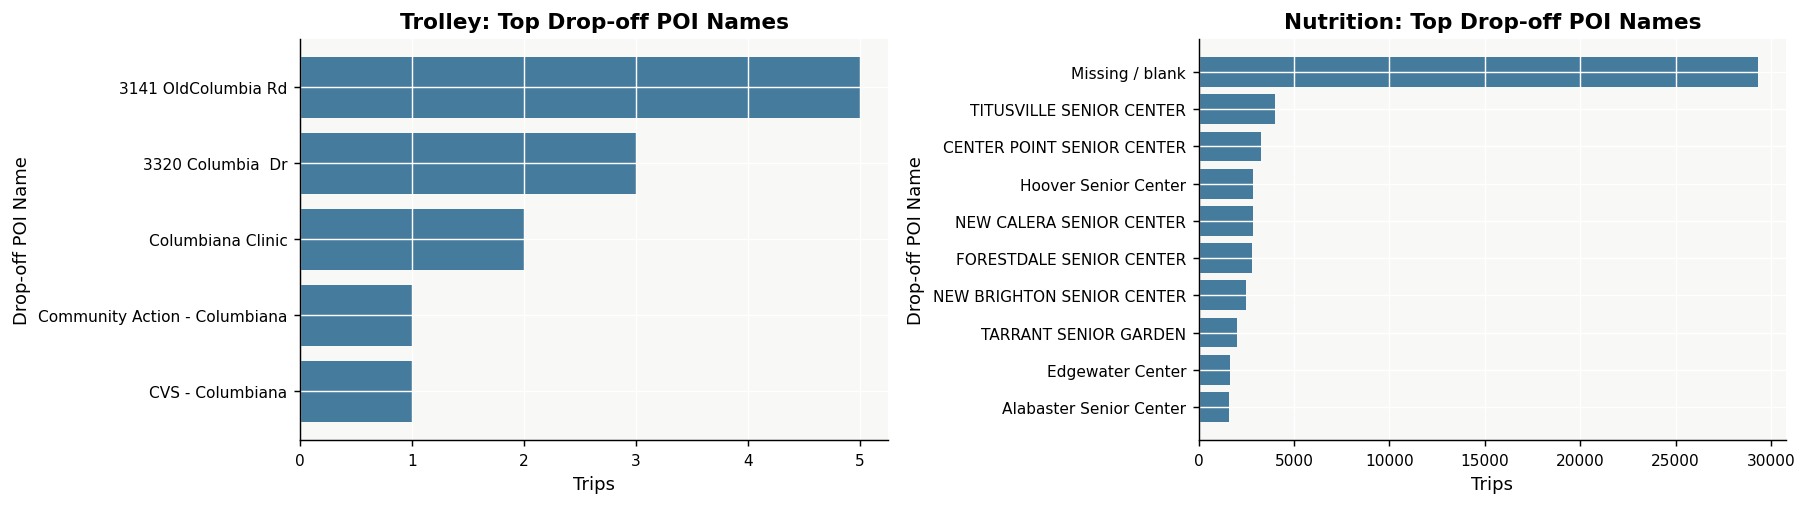

In [7]:
PURPOSES_TO_CHECK = ['Trolley', 'Nutrition']

purpose_poi = df_raw[df_raw['Purpose'].astype(str).str.strip().isin(PURPOSES_TO_CHECK)].copy()
purpose_poi['dropoff_poi_name_clean'] = (
    purpose_poi['Drop-off POI Name']
    .fillna('Missing / blank')
    .astype(str)
    .str.strip()
    .replace('', 'Missing / blank')
)
purpose_poi['status_clean'] = purpose_poi['Trip Status'].astype('string').str.strip().str.lower()

print(f"Trips with Purpose in {PURPOSES_TO_CHECK}: {len(purpose_poi):,}")
print('Purpose counts:')
display(
    purpose_poi['Purpose']
    .value_counts()
    .rename_axis('Purpose')
    .reset_index(name='num_trips')
    .style.format({'num_trips': '{:,.0f}'})
)

purpose_poi_summary = (
    purpose_poi
    .groupby(['Purpose', 'dropoff_poi_name_clean'])
    .agg(
        num_trips=('Trip ID', 'count'),
        completed_trips=('status_clean', lambda s: s.isin(['comp', 'completed']).sum()),
        unique_customers=('Customer Number', 'nunique'),
    )
    .reset_index()
)
purpose_totals = purpose_poi_summary.groupby('Purpose')['num_trips'].transform('sum')
purpose_poi_summary['share_within_purpose'] = purpose_poi_summary['num_trips'] / purpose_totals
purpose_poi_summary = purpose_poi_summary.sort_values(
    ['Purpose', 'num_trips'], ascending=[True, False]
)

print('Top Drop-off POI Names for Trolley and Nutrition:')
display(
    purpose_poi_summary
    .groupby('Purpose')
    .head(20)
    .style.format({
        'num_trips': '{:,.0f}',
        'completed_trips': '{:,.0f}',
        'unique_customers': '{:,.0f}',
        'share_within_purpose': '{:.2%}',
    })
)

fig, axes = plt.subplots(1, len(PURPOSES_TO_CHECK), figsize=(14, 4))
if len(PURPOSES_TO_CHECK) == 1:
    axes = [axes]
for ax, purpose in zip(axes, PURPOSES_TO_CHECK):
    plot_data = (
        purpose_poi_summary[purpose_poi_summary['Purpose'].eq(purpose)]
        .head(10)
        .sort_values('num_trips')
    )
    ax.barh(plot_data['dropoff_poi_name_clean'], plot_data['num_trips'], color='#457b9d')
    ax.set_title(f'{purpose}: Top Drop-off POI Names')
    ax.set_xlabel('Trips')
    ax.set_ylabel('Drop-off POI Name')
plt.tight_layout()
plt.show()


# Here, we discuss the completion rate for each purpose, and we also summarize the cancellation types. 

In [5]:
purpose_completion_rate = (
    df_raw.assign(status_clean=status_clean)
    .dropna(subset=['Purpose'])
    .groupby('Purpose')
    .agg(
        total_trips=('Trip ID', 'count'),
        completed_trips=('status_clean', lambda s: s.isin(['comp', 'completed']).sum()),
        cancelled_trips=('status_clean', lambda s: s.isin(['cancel', 'canceled', 'cancelled']).sum()),
        noshow_trips=('status_clean', lambda s: s.isin(['noshow', 'no show', 'no-show']).sum()),
    )
)

purpose_completion_rate['completed_rate'] = (
    purpose_completion_rate['completed_trips'] / purpose_completion_rate['total_trips']
)
purpose_completion_rate = purpose_completion_rate.sort_values('completed_rate', ascending=False)

display(purpose_completion_rate.style.format({
    'total_trips': '{:,.0f}',
    'completed_trips': '{:,.0f}',
    'cancelled_trips': '{:,.0f}',
    'noshow_trips': '{:,.0f}',
    'completed_rate': '{:.2%}',
}))

cancel_statuses = ['cancel', 'canceled', 'cancelled']
cancelled_mask = status_clean.isin(cancel_statuses)
df_cancelled = df_raw.loc[cancelled_mask].copy()
df_cancelled['cancel_type_clean'] = (
    df_cancelled['Cancel Type']
    .fillna('Missing / Unknown')
    .astype(str)
    .str.strip()
    .replace('', 'Missing / Unknown')
)

total_cancellations = int(cancelled_mask.sum())
cancel_type_summary = (
    df_cancelled
    .groupby('cancel_type_clean')
    .agg(num_cancellations=('Trip ID', 'count'))
    .sort_values('num_cancellations', ascending=False)
)
cancel_type_summary['share_of_cancellations'] = (
    cancel_type_summary['num_cancellations'] / total_cancellations
)

print(f"Total cancellations: {total_cancellations:,}")
print(f"Cancellation types: {cancel_type_summary.shape[0]:,}")
display(cancel_type_summary.style.format({
    'num_cancellations': '{:,.0f}',
    'share_of_cancellations': '{:.2%}',
}))


,total_trips,completed_trips,cancelled_trips,noshow_trips,completed_rate
Purpose,,,,,
Trolley,12,12,0,0,100.00%
Dialysis,"13,186","7,851","5,078",257,59.54%
Workshop,"5,511","3,204","2,245",62,58.14%
Education,"1,526",878,634,14,57.54%
Employment,"13,619","7,818","5,582",219,57.41%
Nutrition,"64,285","36,847","25,229","2,209",57.32%
Recreation,"1,001",409,554,38,40.86%
Shopping,"2,192",668,"1,492",32,30.47%
Medical,"17,015","5,169","11,404",442,30.38%


Total cancellations: 54,121
Cancellation types: 16


,num_cancellations,share_of_cancellations
cancel_type_clean,,
Advanced Cancel,"16,075",29.70%
Trip correction,"16,017",29.59%
Modified,"6,805",12.57%
Renegotiation,"6,650",12.29%
Site closure,"4,310",7.96%
Denial,"2,081",3.85%
Late Cancel,"1,017",1.88%
User Error Cancel,754,1.39%
Policy Cancel,181,0.33%


More flexible purposes may have higher cancellation/adjustment behavior,
while obligatory trips are more regular and less flexible.

# 2. Filter dataset

In [21]:
keep_cols = [
    'Customer Number', 'Trip ID', 'Trip Date', 'Trip Status', 'Run ID',
    'Earliest Pick-up', 'Latest Drop-off Time',
    'Scheduled Pick-up Arrival Time', 'Scheduled Pick-up Departure Time',
    # 'Requested Pick-up Time', 
    'Reported Pick-up Arrival Time', 
    'Reported Pick-up Departure Time',
    # # 'Requested Drop-off Time', 
    'Reported Drop-Off Arrival Time', 
    'Reported Drop-Off Departure Time',
    # 'Pick-up Street', 'Pick-up Street Number', 'Pick-up Zipcode',
    # 'Drop-off Street', 'Drop-off Street Number', 'Drop-off Zipcode',
    'Purpose', 'pickup_address', 'dropoff_address',
    'pickup_lat', 'pickup_lon', 'dropoff_lat', 'dropoff_lon',
]

# Keep only completed trips with complete required timing, address, purpose, and coordinate fields.
df_clean = df_raw[keep_cols].copy()
df_clean = df_clean[df_clean['Trip Status'].astype('string').str.strip().str.lower().isin(['comp', 'completed'])]
df_clean = df_clean.dropna(subset=keep_cols).copy()

print(f"Completed rows after required-column NaN filtering: {len(df_clean):,}")
df_clean.head(3)


Completed rows after required-column NaN filtering: 63,596


,Customer Number,Trip ID,Trip Date,Trip Status,Run ID,Earliest Pick-up,Latest Drop-off Time,Scheduled Pick-up Arrival Time,Scheduled Pick-up Departure Time,Reported Pick-up Arrival Time,Reported Pick-up Departure Time,Reported Drop-Off Arrival Time,Reported Drop-Off Departure Time,Purpose,pickup_address,dropoff_address,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon
1,14909,286738,2022-07-01,comp,E&I-102,05:30:00,06:48:00,2022-07-01 05:45:41,2022-07-01 05:48:41,05:26:00,05:28:00,05:49:00,05:49:00,Employment,"308 Glynn Dr, Birmingham, Al 35215","529 Beacon Pkwy W, Birmingham, AL 35209",33.603306,-86.711765,33.475050,-86.823489
2,6712,286886,2022-07-01,comp,Finch,06:00:00,07:03:00,2022-07-01 06:15:00,2022-07-01 06:18:00,06:54:00,07:04:00,07:23:00,07:32:00,Dialysis,"1520 Chattanooga St, Leeds, Al 35094","7780 Ludington Ln, Irondale, AL 35210",33.546257,-86.558513,33.531577,-86.715948
3,5801,286851,2022-07-01,comp,Finch,06:00:00,07:03:00,2022-07-01 06:15:00,2022-07-01 06:18:00,06:54:00,07:04:00,07:23:00,07:32:00,Dialysis,"1520 Chattanooga St, Leeds, Al 35094","7780 Ludington Ln, Irondale, AL 35210",33.546257,-86.558513,33.531577,-86.715948


### Audit Trolley Trips Removed by `df_clean` Filtering

This cell checks why completed `Trolley` trips may disappear after the strict `df_clean` filter. It compares completed `Trolley` rows in `df_raw` against the required `keep_cols` fields and reports which required columns are missing.


In [22]:
trolley_raw_completed = df_raw[
    df_raw['Purpose'].astype(str).str.strip().eq('Trolley')
    & df_raw['Trip Status'].astype('string').str.strip().str.lower().isin(['comp', 'completed'])
].copy()

trolley_clean = df_clean[df_clean['Purpose'].astype(str).str.strip().eq('Trolley')].copy()

print(f"Completed Trolley trips before df_clean filtering: {len(trolley_raw_completed):,}")
print(f"Trolley trips remaining in df_clean: {len(trolley_clean):,}")
print(f"Completed Trolley trips removed by required-column filtering: {len(trolley_raw_completed) - len(trolley_clean):,}")

if trolley_raw_completed.empty:
    print('No completed Trolley trips found in df_raw.')
else:
    missing_summary = (
        trolley_raw_completed[keep_cols]
        .isna()
        .sum()
        .rename('num_missing')
        .reset_index()
        .rename(columns={'index': 'required_column'})
    )
    missing_summary = missing_summary[missing_summary['num_missing'] > 0]
    missing_summary['share_of_completed_trolley'] = (
        missing_summary['num_missing'] / len(trolley_raw_completed)
    )
    missing_summary = missing_summary.sort_values('num_missing', ascending=False)

    print('Required fields missing among completed Trolley trips:')
    display(missing_summary.style.format({
        'num_missing': '{:,.0f}',
        'share_of_completed_trolley': '{:.2%}',
    }))

    dropped_trolley = trolley_raw_completed.copy()
    dropped_trolley['missing_required_columns'] = dropped_trolley[keep_cols].isna().apply(
        lambda row: ', '.join(row.index[row]), axis=1
    )
    dropped_trolley = dropped_trolley[dropped_trolley['missing_required_columns'] != '']

    print('Dropped completed Trolley trip examples:')
    display_cols = [
        'Trip ID', 'Trip Date', 'Drop-off POI Name',
        'Scheduled Pick-up Arrival Time', 'Scheduled Pick-up Departure Time',
        'Reported Pick-up Arrival Time', 'Reported Pick-up Departure Time',
        'Reported Drop-Off Arrival Time', 'Reported Drop-Off Departure Time',
        'missing_required_columns',
    ]
    display(dropped_trolley[display_cols].head(20))


Completed Trolley trips before df_clean filtering: 12
Trolley trips remaining in df_clean: 12
Completed Trolley trips removed by required-column filtering: 0
Required fields missing among completed Trolley trips:


,required_column,num_missing,share_of_completed_trolley


Dropped completed Trolley trip examples:


,Trip ID,Trip Date,Drop-off POI Name,Scheduled Pick-up Arrival Time,Scheduled Pick-up Departure Time,Reported Pick-up Arrival Time,Reported Pick-up Departure Time,Reported Drop-Off Arrival Time,Reported Drop-Off Departure Time,missing_required_columns


# Time of Day distribution from Earliest pickup time for different purpose

Completed-trip demand by earliest pickup hour and purpose:


pickup_hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
Purpose,,,,,,,,,,,,,,,,,,,,,,,,
Nutrition,0,0,0,0,0,0,136,"6,695","10,894",311,271,506,"8,602","9,372",59,1,0,0,0,0,0,0,0,0
Dialysis,0,0,0,0,0,73,260,2,440,"2,132","1,168",255,570,97,"1,063","1,716",72,3,0,0,0,0,0,0
Employment,0,0,0,0,0,223,869,560,675,956,128,518,134,413,"1,176","1,585",580,1,0,0,0,0,0,0
Medical,0,0,0,0,0,0,15,202,606,"1,078",635,596,694,602,432,293,16,0,0,0,0,0,0,0
Workshop,0,0,0,0,0,0,336,965,188,101,0,0,5,3,"1,412",193,1,0,0,0,0,0,0,0
Education,0,0,0,0,0,0,36,266,43,80,2,30,86,3,270,61,1,0,0,0,0,0,0,0
Personal,0,0,0,0,0,0,0,3,36,158,132,78,129,90,85,28,1,0,0,0,0,0,0,0
Shopping,0,0,0,0,0,0,0,0,8,122,170,61,71,133,81,21,1,0,0,0,0,0,0,0
Recreation,0,0,0,0,0,0,2,62,46,58,31,18,58,62,64,3,5,0,0,0,0,0,0,0


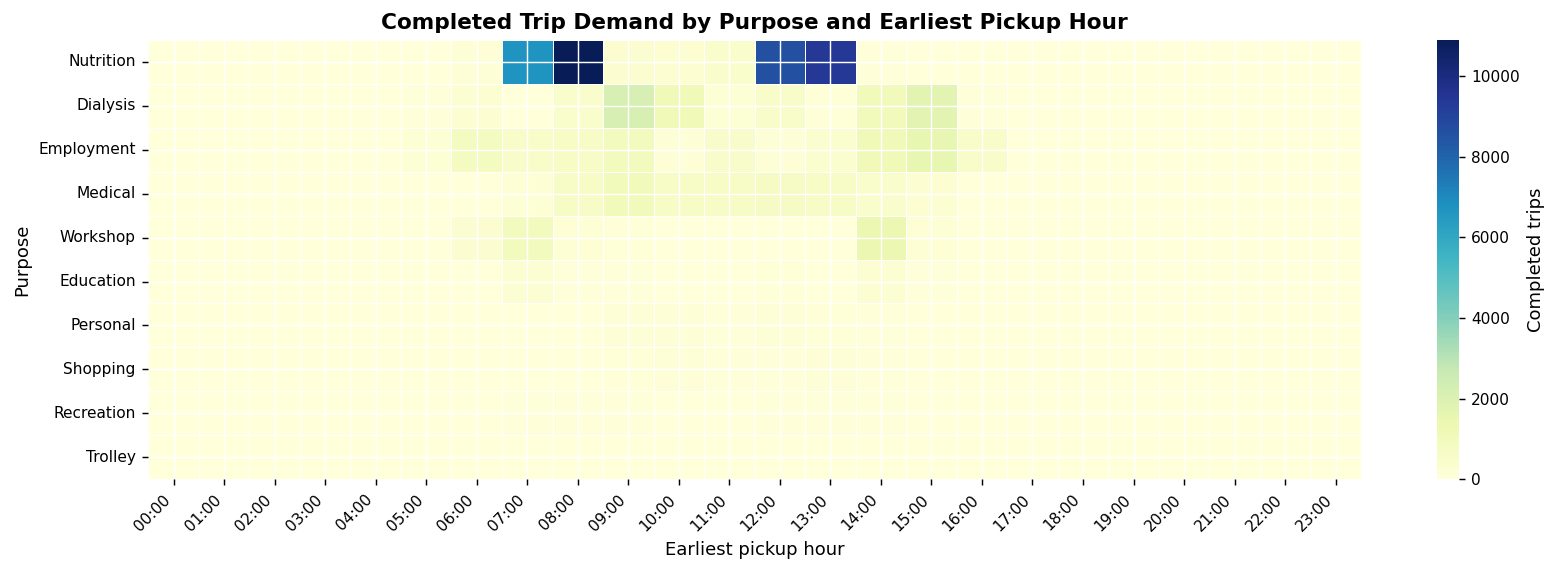

In [23]:
def hour_from_time(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip()
    if not s:
        return np.nan
    try:
        return int(s.split(':')[0])
    except Exception:
        dt = pd.to_datetime(s, errors='coerce')
        return np.nan if pd.isna(dt) else dt.hour

df_time_demand = df_clean.copy()
df_time_demand['pickup_hour'] = df_time_demand['Earliest Pick-up'].apply(hour_from_time)
df_time_demand = df_time_demand.dropna(subset=['Purpose', 'pickup_hour']).copy()
df_time_demand['pickup_hour'] = df_time_demand['pickup_hour'].astype(int)

purpose_hourly_demand = (
    df_time_demand
    .groupby(['Purpose', 'pickup_hour'])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)

purpose_hourly_demand = purpose_hourly_demand.loc[
    purpose_hourly_demand.sum(axis=1).sort_values(ascending=False).index
]

print('Completed-trip demand by earliest pickup hour and purpose:')
display(purpose_hourly_demand.style.format('{:,.0f}'))

fig, ax = plt.subplots(figsize=(13, max(3.5, 0.45 * len(purpose_hourly_demand))))
sns.heatmap(
    purpose_hourly_demand,
    cmap='YlGnBu',
    linewidths=0.4,
    linecolor='white',
    cbar_kws={'label': 'Completed trips'},
    ax=ax,
)
ax.set_title('Completed Trip Demand by Purpose and Earliest Pickup Hour')
ax.set_xlabel('Earliest pickup hour')
ax.set_ylabel('Purpose')
ax.set_xticklabels([f'{h:02d}:00' for h in range(24)], rotation=45, ha='right')
plt.tight_layout()


# Add POI dataset

In [ ]:
POI_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/birmingham_pois.csv')
poi_categories = pd.read_csv(POI_PATH)
poi_categories = poi_categories.dropna(subset=['lat', 'lon']).copy()
poi_categories['poi_name'] = poi_categories['name'].fillna('Unknown POI').astype(str)
poi_categories['poi_top_category'] = poi_categories['top_category'].fillna('Unknown category').astype(str)
poi_categories['poi_sub_category'] = poi_categories['sub_category'].fillna('Unknown sub-category').astype(str)
poi_categories['poi_address'] = poi_categories['address'].fillna('Unknown address').astype(str)


def add_nearest_poi_category(locations, lat_col, lon_col, prefix, max_distance_m=250):
    result = locations.reset_index(drop=True).copy()
    if result.empty:
        return result

    location_coords = np.radians(result[[lat_col, lon_col]].to_numpy(dtype=float))
    poi_coords = np.radians(poi_categories[['lat', 'lon']].to_numpy(dtype=float))

    dlat = location_coords[:, None, 0] - poi_coords[None, :, 0]
    dlon = location_coords[:, None, 1] - poi_coords[None, :, 1]
    haversine_a = (
        np.sin(dlat / 2) ** 2
        + np.cos(location_coords[:, None, 0])
        * np.cos(poi_coords[None, :, 0])
        * np.sin(dlon / 2) ** 2
    )
    distance_m = 2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000
    nearest_idx = distance_m.argmin(axis=1)
    nearest_distance_m = distance_m[np.arange(len(result)), nearest_idx]
    nearest_pois = poi_categories.iloc[nearest_idx].reset_index(drop=True)
    nearby_mask = nearest_distance_m <= max_distance_m

    result[f'{prefix}_nearest_poi_name'] = nearest_pois['poi_name']
    result[f'{prefix}_nearest_poi_address'] = nearest_pois['poi_address']
    result[f'{prefix}_nearest_poi_distance_m'] = nearest_distance_m
    result[f'{prefix}_poi_top_category'] = np.where(
        nearby_mask,
        nearest_pois['poi_top_category'],
        f'No nearby POI within {max_distance_m}m',
    )
    result[f'{prefix}_poi_sub_category'] = np.where(
        nearby_mask,
        nearest_pois['poi_sub_category'],
        f'No nearby POI within {max_distance_m}m',
    )
    result[f'{prefix}_poi_match_status'] = np.where(
        nearby_mask,
        f'matched within {max_distance_m}m',
        f'nearest POI farther than {max_distance_m}m',
    )
    return result


top_pickup_locations = (
    df_clean
    .groupby(['pickup_address', 'pickup_lat', 'pickup_lon'])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
        num_purposes=('Purpose', 'nunique'),
    )
    .reset_index()
    .sort_values(['num_trips', 'num_customers'], ascending=False)
    .head(20)
)
top_pickup_locations.insert(0, 'rank', range(1, len(top_pickup_locations) + 1))
top_pickup_locations = add_nearest_poi_category(
    top_pickup_locations, 'pickup_lat', 'pickup_lon', 'pickup'
)

top_dropoff_locations = (
    df_clean
    .groupby(['dropoff_address', 'dropoff_lat', 'dropoff_lon'])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
        num_purposes=('Purpose', 'nunique'),
    )
    .reset_index()
    .sort_values(['num_trips', 'num_customers'], ascending=False)
    .head(20)
)
top_dropoff_locations.insert(0, 'rank', range(1, len(top_dropoff_locations) + 1))
top_dropoff_locations = add_nearest_poi_category(
    top_dropoff_locations, 'dropoff_lat', 'dropoff_lon', 'dropoff'
)

top_od_pairs = (
    df_clean
    .groupby([
        'pickup_address', 'pickup_lat', 'pickup_lon',
        'dropoff_address', 'dropoff_lat', 'dropoff_lon',
    ])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
        num_purposes=('Purpose', 'nunique'),
    )
    .reset_index()
    .sort_values(['num_trips', 'num_customers'], ascending=False)
    .head(20)
)
top_od_pairs.insert(0, 'rank', range(1, len(top_od_pairs) + 1))
top_od_pairs = add_nearest_poi_category(top_od_pairs, 'pickup_lat', 'pickup_lon', 'pickup')
top_od_pairs = add_nearest_poi_category(top_od_pairs, 'dropoff_lat', 'dropoff_lon', 'dropoff')

purpose_top_od_pairs = (
    df_clean
    .groupby([
        'Purpose',
        'pickup_address', 'pickup_lat', 'pickup_lon',
        'dropoff_address', 'dropoff_lat', 'dropoff_lon',
    ])
    .agg(
        num_trips=('Trip ID', 'count'),
        num_customers=('Customer Number', 'nunique'),
    )
    .reset_index()
)
purpose_top_od_pairs = purpose_top_od_pairs.sort_values(
    ['Purpose', 'num_trips', 'num_customers'], ascending=[True, False, False]
)
purpose_top_od_pairs['rank_within_purpose'] = (
    purpose_top_od_pairs.groupby('Purpose').cumcount() + 1
)
purpose_top_od_pairs = purpose_top_od_pairs.query('rank_within_purpose <= 5')
purpose_top_od_pairs = add_nearest_poi_category(
    purpose_top_od_pairs, 'pickup_lat', 'pickup_lon', 'pickup'
)
purpose_top_od_pairs = add_nearest_poi_category(
    purpose_top_od_pairs, 'dropoff_lat', 'dropoff_lon', 'dropoff'
)

count_format = {
    'rank': '{:,.0f}',
    'rank_within_purpose': '{:,.0f}',
    'num_trips': '{:,.0f}',
    'num_customers': '{:,.0f}',
    'num_purposes': '{:,.0f}',
    'pickup_lat': '{:.6f}',
    'pickup_lon': '{:.6f}',
    'dropoff_lat': '{:.6f}',
    'dropoff_lon': '{:.6f}',
    'pickup_nearest_poi_distance_m': '{:,.1f}',
    'dropoff_nearest_poi_distance_m': '{:,.1f}',
}

print('Top 20 pickup locations from completed trips with nearest Birmingham POI category:')
display(top_pickup_locations.style.format(count_format))

print('Top 20 drop-off locations from completed trips with nearest Birmingham POI category:')
display(top_dropoff_locations.style.format(count_format))

print('Top 20 OD pairs from completed trips with pickup/drop-off POI categories:')
display(top_od_pairs.style.format(count_format))

print('Top 5 OD pairs within each purpose from completed trips with pickup/drop-off POI categories:')
display(purpose_top_od_pairs.style.format(count_format))



### Rider Regularity Index

This cell measures how routine each rider's completed-trip behavior is. For each customer, it summarizes trip frequency, unique pickup/drop-off/OD patterns, pickup-hour consistency, purpose consistency, and weekday consistency.

The regularity index is computed as:

```text
Rider_regularity_index = 0.4 * OD_regular_i
                       + 0.3 * time_regular_i
                       + 0.2 * purpose_regular_i
                       + 0.1 * weekday_regular_i
```

where each component is a dominant-share measure. A higher value means the rider tends to repeat the same OD pair, time, purpose, and weekday pattern. This score is later subtracted from the flexibility index because highly regular behavior indicates less flexibility.



#### How the regularity components are calculated

For each rider $i$, the notebook groups completed trips by `Customer Number` and calculates each component as a dominant-share score, meaning the share of that rider's trips that fall into their most common category:

- $OD\_regular_i = \max_{od}\; n_{i,od} / N_i$: the fraction of rider $i$'s completed trips using their most frequent origin-destination pair. The OD pair is built from pickup address/coordinates and drop-off address/coordinates.
- $time\_regular_i = \max_{h}\; n_{i,h} / N_i$: the fraction of trips in rider $i$'s most common requested pickup hour, derived from `Earliest Pick-up`.
- $purpose\_regular_i = \max_{p}\; n_{i,p} / N_i$: the fraction of trips with rider $i$'s most common trip `Purpose`.
- $weekday\_regular_i = \max_{d}\; n_{i,d} / N_i$: the fraction of trips on rider $i$'s most common weekday, derived from `Trip Date`.

Here, $N_i$ is rider $i$'s total number of completed trips in `df_clean`. Each score ranges from 0 to 1. Values closer to 1 mean trips are concentrated in one repeated pattern; lower values mean trips are spread across several OD pairs, hours, purposes, or weekdays.



In [ ]:
def entropy_from_counts(counts):
    counts = np.asarray(counts, dtype=float)
    total = counts.sum()
    if total == 0:
        return np.nan
    probabilities = counts[counts > 0] / total
    return -(probabilities * np.log2(probabilities)).sum()


def dominant_share(s):
    counts = s.dropna().value_counts()
    if counts.empty:
        return np.nan
    return counts.iloc[0] / counts.sum()


def pickup_hour_std(s):
    values = s.dropna()
    if values.empty:
        return np.nan
    return values.std(ddof=0)


def entropy_for_series(s):
    return entropy_from_counts(s.dropna().value_counts().to_numpy())

rider_trips = df_clean.copy()
rider_trips['pickup_hour'] = rider_trips['Earliest Pick-up'].apply(hour_from_time)
rider_trips['trip_date_parsed'] = pd.to_datetime(rider_trips['Trip Date'], errors='coerce')
rider_trips['weekday'] = rider_trips['trip_date_parsed'].dt.day_name()
rider_trips['pickup_location_key'] = (
    rider_trips[['pickup_address', 'pickup_lat', 'pickup_lon']].astype(str).agg('|'.join, axis=1)
)
rider_trips['dropoff_location_key'] = (
    rider_trips[['dropoff_address', 'dropoff_lat', 'dropoff_lon']].astype(str).agg('|'.join, axis=1)
)
rider_trips['od_pair_key'] = (
    rider_trips['pickup_location_key'] + ' -> ' + rider_trips['dropoff_location_key']
)

rider_regularity = (
    rider_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        num_unique_pickups=('pickup_location_key', 'nunique'),
        num_unique_dropoffs=('dropoff_location_key', 'nunique'),
        num_unique_OD_pairs=('od_pair_key', 'nunique'),
        dominant_OD_share=('od_pair_key', dominant_share),
        pickup_hour_std=('pickup_hour', pickup_hour_std),
        dominant_pickup_hour_share=('pickup_hour', dominant_share),
        time_entropy=('pickup_hour', entropy_for_series),
        num_unique_purposes=('Purpose', 'nunique'),
        dominant_purpose_share=('Purpose', dominant_share),
        num_active_weekdays=('weekday', 'nunique'),
        dominant_weekday_share=('weekday', dominant_share),
        weekday_entropy=('weekday', entropy_for_series),
    )
    .reset_index()
)

rider_regularity['OD_regular_i'] = rider_regularity['dominant_OD_share']
rider_regularity['time_regular_i'] = rider_regularity['dominant_pickup_hour_share']
rider_regularity['purpose_regular_i'] = rider_regularity['dominant_purpose_share']
rider_regularity['weekday_regular_i'] = rider_regularity['dominant_weekday_share']
rider_regularity['Rider_regularity_index'] = (
    0.4 * rider_regularity['OD_regular_i']
    + 0.3 * rider_regularity['time_regular_i']
    + 0.2 * rider_regularity['purpose_regular_i']
    + 0.1 * rider_regularity['weekday_regular_i']
)

rider_regularity = rider_regularity.sort_values(
    ['Rider_regularity_index', 'trip_frequency'], ascending=[False, False]
)

print(f"Customers in completed-trip regularity analysis: {len(rider_regularity):,}")
print(
    f"Mean Rider Regularity Index: {rider_regularity['Rider_regularity_index'].mean():.3f}; "
    f"Median: {rider_regularity['Rider_regularity_index'].median():.3f}"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].hist(
    rider_regularity['Rider_regularity_index'],
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
    alpha=0.9,
)
axes[0].axvline(
    rider_regularity['Rider_regularity_index'].mean(),
    color='#d62828',
    linestyle='--',
    linewidth=1.5,
    label='Mean',
)
axes[0].set_title('Distribution of Rider Regularity Index')
axes[0].set_xlabel('Rider regularity index')
axes[0].set_ylabel('Number of riders')
axes[0].legend()

component_data = [
    rider_regularity['OD_regular_i'].dropna(),
    rider_regularity['time_regular_i'].dropna(),
    rider_regularity['purpose_regular_i'].dropna(),
    rider_regularity['weekday_regular_i'].dropna(),
]
box = axes[1].boxplot(
    component_data,
    labels=['OD', 'Time', 'Purpose', 'Weekday'],
    patch_artist=True,
    showfliers=False,
)
for patch, color in zip(box['boxes'], ['#457b9d', '#e9c46a', '#f4a261', '#8ab17d']):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
axes[1].set_title('Regularity Components Across Riders')
axes[1].set_ylabel('Dominant-share regularity score')
axes[1].set_ylim(0, 1.05)

plt.tight_layout()
plt.show()



### Actual Pickup Time From Vehicle Route Events

This cell links completed trips to `vehicle_tour_segments.csv` to recover route-event pickup times. Pickup events are identified where `event_at_start == 'PICKUP'` and are matched to trips using customer, date, run/vehicle, and pickup-coordinate proximity.

The resulting fields include `actual_pickup_timestamp`, `actual_pickup_time`, and `actual_pickup_hour`. In this dataset, the matched actual pickup time is almost always equal to `Earliest Pick-up`, so the pickup deviation term has limited variation.



In [ ]:
ROUTE_SEGMENTS_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/vehicle_tour_segments.csv')
vehicle_segments = pd.read_csv(ROUTE_SEGMENTS_PATH, low_memory=False)

pickup_events = vehicle_segments[
    vehicle_segments['event_at_start'].astype('string').str.upper().eq('PICKUP')
].copy()
pickup_events['trip_date_key'] = pd.to_datetime(pickup_events['Date/Time'], errors='coerce').dt.date
pickup_events['customer_key'] = pd.to_numeric(pickup_events['rider_at_start'], errors='coerce')
pickup_events['run_key'] = pd.to_numeric(pickup_events['Vehicle'], errors='coerce')
pickup_events['actual_pickup_timestamp'] = pd.to_datetime(
    pickup_events['Date/Time'].astype(str).str[:10] + ' ' + pickup_events['Depart'].astype(str),
    errors='coerce',
)
pickup_events = pickup_events.dropna(
    subset=['trip_date_key', 'customer_key', 'run_key', 'actual_pickup_timestamp', 'StartLatitude', 'StartLongitude']
).copy()
pickup_events = pickup_events.reset_index().rename(columns={'index': 'pickup_event_id'})

trips_for_actual_pickup = df_clean.copy()
trips_for_actual_pickup['trip_date_key'] = pd.to_datetime(
    trips_for_actual_pickup['Trip Date'], errors='coerce'
).dt.date
trips_for_actual_pickup['customer_key'] = pd.to_numeric(
    trips_for_actual_pickup['Customer Number'], errors='coerce'
)
trips_for_actual_pickup['run_key'] = pd.to_numeric(trips_for_actual_pickup['Run ID'], errors='coerce')
trips_for_actual_pickup['scheduled_pickup_timestamp'] = pd.to_datetime(
    trips_for_actual_pickup['Trip Date'].astype(str) + ' ' + trips_for_actual_pickup['Earliest Pick-up'].astype(str),
    errors='coerce',
)

pickup_candidates = trips_for_actual_pickup.merge(
    pickup_events[[
        'pickup_event_id', 'trip_date_key', 'customer_key', 'run_key',
        'actual_pickup_timestamp', 'Depart', 'StartLatitude', 'StartLongitude',
        'trip_ids_on_board', 'next_action',
    ]],
    on=['trip_date_key', 'customer_key', 'run_key'],
    how='left',
)

# Distance between trip pickup coordinate and route-event start coordinate.
pickup_candidates['pickup_event_distance_m'] = np.nan
matched_candidate_mask = pickup_candidates['pickup_event_id'].notna()
if matched_candidate_mask.any():
    lat1 = np.radians(pickup_candidates.loc[matched_candidate_mask, 'pickup_lat'].astype(float))
    lon1 = np.radians(pickup_candidates.loc[matched_candidate_mask, 'pickup_lon'].astype(float))
    lat2 = np.radians(pickup_candidates.loc[matched_candidate_mask, 'StartLatitude'].astype(float))
    lon2 = np.radians(pickup_candidates.loc[matched_candidate_mask, 'StartLongitude'].astype(float))
    haversine_a = (
        np.sin((lat1 - lat2) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon1 - lon2) / 2) ** 2
    )
    pickup_candidates.loc[matched_candidate_mask, 'pickup_event_distance_m'] = (
        2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000
    )

pickup_candidates['actual_vs_scheduled_pickup_min'] = (
    pickup_candidates['actual_pickup_timestamp']
    - pickup_candidates['scheduled_pickup_timestamp']
).dt.total_seconds() / 60
pickup_candidates['abs_actual_vs_scheduled_pickup_min'] = (
    pickup_candidates['actual_vs_scheduled_pickup_min'].abs()
)

best_pickup_matches = (
    pickup_candidates
    .dropna(subset=['pickup_event_id'])
    .sort_values([
        'Trip ID', 'pickup_event_distance_m', 'abs_actual_vs_scheduled_pickup_min'
    ])
    .drop_duplicates('Trip ID')
)
best_pickup_matches = best_pickup_matches[
    best_pickup_matches['pickup_event_distance_m'] <= 150
].copy()

actual_pickup_lookup = best_pickup_matches.set_index('Trip ID')[[
    'actual_pickup_timestamp', 'pickup_event_distance_m', 'actual_vs_scheduled_pickup_min',
    'pickup_event_id', 'trip_ids_on_board', 'next_action',
]]

actual_pickup_cols = [
    'actual_pickup_timestamp', 'pickup_event_distance_m', 'actual_vs_scheduled_pickup_min',
    'pickup_event_id', 'trip_ids_on_board', 'next_action',
    'actual_pickup_time', 'actual_pickup_hour',
]
df_clean = df_clean.drop(columns=[c for c in actual_pickup_cols if c in df_clean.columns])

df_clean = df_clean.merge(
    actual_pickup_lookup,
    left_on='Trip ID',
    right_index=True,
    how='left',
)
df_clean['actual_pickup_time'] = df_clean['actual_pickup_timestamp'].dt.strftime('%H:%M:%S')
df_clean['actual_pickup_hour'] = df_clean['actual_pickup_timestamp'].dt.hour

matched_trips = df_clean['actual_pickup_timestamp'].notna().sum()
print(f"Vehicle pickup events: {len(pickup_events):,}")
print(f"Completed trips with matched actual pickup time: {matched_trips:,} / {len(df_clean):,} ({matched_trips / len(df_clean):.1%})")
print(f"Median pickup-coordinate match distance: {df_clean['pickup_event_distance_m'].median():.1f} meters")
print(f"Median actual minus scheduled earliest pickup: {df_clean['actual_vs_scheduled_pickup_min'].median():.1f} minutes")

actual_pickup_summary = df_clean[[
    'Customer Number', 'Trip ID', 'Trip Date', 'Run ID', 'Purpose',
    'Earliest Pick-up', 'actual_pickup_time', 'actual_pickup_hour',
    'actual_vs_scheduled_pickup_min', 'pickup_event_distance_m',
    'pickup_address', 'dropoff_address',
]].sort_values(['Trip Date', 'Run ID', 'actual_pickup_time'])

display(actual_pickup_summary.head(20).style.format({
    'actual_vs_scheduled_pickup_min': '{:,.1f}',
    'pickup_event_distance_m': '{:,.1f}',
}))




### Temporal Flexibility Index

This cell computes a rider-level temporal flexibility score from two pieces: pickup-deviation flexibility and requested pickup-time diversity.

First, for each matched trip, pickup deviation is measured in minutes:

```text
E_trip = actual_pickup_time - earliest_pickup_time
```

Then, for each rider/customer `i`, the notebook calculates the mean pickup deviation across that rider's matched trips:

```text
average_E_i = mean(E_trip for all matched trips of rider i)
```

Because `average_E_i` is measured in minutes and pickup-time entropy is measured in bits, both rider-level terms are min-max normalized before they are combined:

```text
average_E_i_norm = minmax(average_E_i)
earliest_pickup_time_entropy_norm = minmax(earliest_pickup_time_entropy)

temporal_flexibility_index = 0.5 * average_E_i_norm
                           + 0.5 * earliest_pickup_time_entropy_norm
```

The normalized mean pickup-deviation term captures whether a rider tends to have larger actual-minus-earliest pickup deviations compared with other riders. The normalized entropy term captures how spread out the rider's requested pickup hours are. Equal 0.5 weights give these two temporal-flexibility components the same contribution to the index.


In [ ]:
temporal_flexibility_trips = df_clean.copy()
temporal_flexibility_trips['earliest_pickup_timestamp'] = pd.to_datetime(
    temporal_flexibility_trips['Trip Date'].astype(str)
    + ' '
    + temporal_flexibility_trips['Earliest Pick-up'].astype(str),
    errors='coerce',
)
temporal_flexibility_trips['earliest_pickup_hour'] = (
    temporal_flexibility_trips['Earliest Pick-up'].apply(hour_from_time)
)

# E_i is measured in minutes: actual pickup time minus requested earliest pickup time.
temporal_flexibility_trips['E_i_actual_minus_earliest_pickup_min'] = (
    temporal_flexibility_trips['actual_pickup_timestamp']
    - temporal_flexibility_trips['earliest_pickup_timestamp']
).dt.total_seconds() / 60

def entropy_bits(s):
    counts = s.dropna().value_counts().to_numpy(dtype=float)
    total = counts.sum()
    if total == 0:
        return np.nan
    probabilities = counts[counts > 0] / total
    return -(probabilities * np.log2(probabilities)).sum()


def minmax_normalize_series(s):
    s = s.astype(float)
    s_min = s.min(skipna=True)
    s_max = s.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(0.0, index=s.index)
    return (s - s_min) / (s_max - s_min)

customer_temporal_flexibility = (
    temporal_flexibility_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        matched_actual_pickup_trips=('actual_pickup_timestamp', 'count'),
        average_E_i=('E_i_actual_minus_earliest_pickup_min', 'mean'),
        median_E_i_min=('E_i_actual_minus_earliest_pickup_min', 'median'),
        earliest_pickup_time_entropy=('earliest_pickup_hour', entropy_bits),
        num_unique_earliest_pickup_hours=('earliest_pickup_hour', 'nunique'),
    )
    .reset_index()
)
customer_temporal_flexibility['actual_pickup_match_rate'] = (
    customer_temporal_flexibility['matched_actual_pickup_trips']
    / customer_temporal_flexibility['trip_frequency']
)
customer_temporal_flexibility['average_E_i_norm'] = minmax_normalize_series(
    customer_temporal_flexibility['average_E_i']
)
customer_temporal_flexibility['earliest_pickup_time_entropy_norm'] = minmax_normalize_series(
    customer_temporal_flexibility['earliest_pickup_time_entropy']
)
customer_temporal_flexibility['temporal_flexibility_index'] = (
    0.5 * customer_temporal_flexibility['average_E_i_norm']
    + 0.5 * customer_temporal_flexibility['earliest_pickup_time_entropy_norm']
)
customer_temporal_flexibility = customer_temporal_flexibility.sort_values(
    ['temporal_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

print(
    f"Trips with E_i available: "
    f"{temporal_flexibility_trips['E_i_actual_minus_earliest_pickup_min'].notna().sum():,} / "
    f"{len(temporal_flexibility_trips):,}"
)
print(f"Customers with temporal flexibility index: {customer_temporal_flexibility['temporal_flexibility_index'].notna().sum():,}")

display(customer_temporal_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'matched_actual_pickup_trips': '{:,.0f}',
    'actual_pickup_match_rate': '{:.1%}',
    'average_E_i': '{:,.2f}',
    'average_E_i_norm': '{:.3f}',
    'median_E_i_min': '{:,.2f}',
    'earliest_pickup_time_entropy': '{:,.2f}',
    'earliest_pickup_time_entropy_norm': '{:.3f}',
    'num_unique_earliest_pickup_hours': '{:,.0f}',
    'temporal_flexibility_index': '{:.3f}',
}))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(
    temporal_flexibility_trips['E_i_actual_minus_earliest_pickup_min'].dropna(),
    bins=40,
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Trip-Level Actual Pickup Deviation')
axes[0].set_xlabel('E_i: actual - earliest pickup (minutes)')
axes[0].set_ylabel('Trips')

axes[1].hist(
    customer_temporal_flexibility['earliest_pickup_time_entropy'].dropna(),
    bins=25,
    color='#f4a261',
    edgecolor='white',
)
axes[1].set_title('Customer Earliest Pickup Time Entropy')
axes[1].set_xlabel('Entropy across earliest pickup hours')
axes[1].set_ylabel('Customers')

axes[2].hist(
    customer_temporal_flexibility['temporal_flexibility_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[2].set_title('Customer Temporal Flexibility Index')
axes[2].set_xlabel('0.5 * normalized E_i + 0.5 * normalized entropy')
axes[2].set_ylabel('Customers')

plt.tight_layout()
plt.show()


I found that all routes have the same pickup time with the earliest pickup time.

### Geographical Flexibility Index

This cell measures how spatially flexible each rider's completed destinations are. It combines three components:

```text
GF_r = 0.3 * destination_diversity_score
     + 0.3 * destination_radius_score_norm
     + 0.4 * alternative_location_availability_score
```

Each component is calculated as follows:

```text
destination_diversity_score_i = H(destination_zone_i) / log(K_i)

destination_radius_m_i = mean(distance from each destination to rider i's destination center)
destination_radius_score_norm_i = destination_radius_m_i / max(destination_radius_m across riders)

alternative_location_score_j = log(1 + similar_POI_count_j) / log(1 + max_similar_POI_count)
alternative_location_availability_score_i = mean(alternative_location_score_j for rider i's destinations)
```

Here, `H(destination_zone_i)` is entropy over rider `i`'s observed drop-off zones, and `K_i` is the number of unique destination zones for rider `i`. If a rider has only one destination zone, the normalized entropy score is set to `0.0`.

`destination_diversity_score` is normalized entropy over the rider's drop-off destination zones, using drop-off addresses before CBG zones are created.

The average destination center is calculated separately for each rider/customer by taking the arithmetic mean of that rider's completed-trip drop-off coordinates:

```text
destination_center_lat_i = mean(dropoff_lat for rider i)
destination_center_lon_i = mean(dropoff_lon for rider i)
```

Then each completed destination is compared with that rider-specific center using the haversine distance. `destination_radius_m` is the rider's mean distance from their drop-off points to this center, and `destination_radius_score_norm` normalizes that radius by the maximum rider radius in the dataset.

`alternative_location_availability_score` uses `birmingham_pois.csv` to estimate whether each destination has similar nearby alternatives. First, each unique drop-off location is assigned a POI category only if its nearest POI is within `NEAREST_POI_MATCH_RADIUS_M = 250` meters. If a drop-off location has no POI within 250 meters, its `similar_POI_count_j` stays `0`, so its `alternative_location_score_j` is also `0`. For matched destinations, the notebook counts POIs with the same top category within `ALTERNATIVE_RADIUS_M = 800` meters. POIs within `SELF_POI_EXCLUSION_RADIUS_M = 25` meters are excluded so the destination's own matched POI is not counted as an alternative. The count is log-normalized and then averaged across each rider's trips.

A higher score means the rider has more diverse destinations, travels across a wider destination area, and/or tends to visit locations with more nearby substitutes.



In [ ]:
POI_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/birmingham_pois.csv')
poi_geo = pd.read_csv(POI_PATH)
poi_geo = poi_geo.dropna(subset=['lat', 'lon', 'top_category']).copy()
poi_geo['poi_top_category'] = poi_geo['top_category'].fillna('Unknown category').astype(str)
poi_geo['poi_sub_category'] = poi_geo['sub_category'].fillna('Unknown sub-category').astype(str)
poi_geo['poi_name'] = poi_geo['name'].fillna('Unknown POI').astype(str)

ALTERNATIVE_RADIUS_M = 800
NEAREST_POI_MATCH_RADIUS_M = 250
SELF_POI_EXCLUSION_RADIUS_M = 25


def haversine_matrix_m(lat1, lon1, lat2, lon2):
    lat1 = np.radians(np.asarray(lat1, dtype=float))[:, None]
    lon1 = np.radians(np.asarray(lon1, dtype=float))[:, None]
    lat2 = np.radians(np.asarray(lat2, dtype=float))[None, :]
    lon2 = np.radians(np.asarray(lon2, dtype=float))[None, :]
    haversine_a = (
        np.sin((lat1 - lat2) / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin((lon1 - lon2) / 2) ** 2
    )
    return 2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000


def normalized_entropy(s):
    counts = s.dropna().value_counts().to_numpy(dtype=float)
    if len(counts) <= 1:
        return 0.0
    probabilities = counts / counts.sum()
    entropy = -(probabilities * np.log(probabilities)).sum()
    return entropy / np.log(len(counts))


geography_trips = df_clean.copy()
geography_trips['destination_zone'] = geography_trips['dropoff_address'].astype(str)

unique_destinations = (
    geography_trips[['dropoff_address', 'dropoff_lat', 'dropoff_lon']]
    .drop_duplicates()
    .reset_index(drop=True)
)

poi_distances_m = haversine_matrix_m(
    unique_destinations['dropoff_lat'],
    unique_destinations['dropoff_lon'],
    poi_geo['lat'],
    poi_geo['lon'],
)
nearest_poi_idx = poi_distances_m.argmin(axis=1)
nearest_poi_distance_m = poi_distances_m[np.arange(len(unique_destinations)), nearest_poi_idx]
nearest_pois = poi_geo.iloc[nearest_poi_idx].reset_index(drop=True)
matched_nearest_poi = nearest_poi_distance_m <= NEAREST_POI_MATCH_RADIUS_M

unique_destinations['nearest_poi_name'] = nearest_pois['poi_name']
unique_destinations['nearest_poi_top_category'] = np.where(
    matched_nearest_poi,
    nearest_pois['poi_top_category'],
    'No nearby POI category',
)
unique_destinations['nearest_poi_sub_category'] = np.where(
    matched_nearest_poi,
    nearest_pois['poi_sub_category'],
    'No nearby POI sub-category',
)
unique_destinations['nearest_poi_distance_m'] = nearest_poi_distance_m

alternative_counts = np.zeros(len(unique_destinations), dtype=int)
poi_categories_array = poi_geo['poi_top_category'].to_numpy()
for i, category in enumerate(unique_destinations['nearest_poi_top_category']):
    if category == 'No nearby POI category':
        continue
    same_category = poi_categories_array == category
    nearby_same_category = poi_distances_m[i, same_category] <= ALTERNATIVE_RADIUS_M
    not_self_location = poi_distances_m[i, same_category] > SELF_POI_EXCLUSION_RADIUS_M
    alternative_counts[i] = int((nearby_same_category & not_self_location).sum())

unique_destinations['similar_pois_within_radius'] = alternative_counts
max_alternative_count = unique_destinations['similar_pois_within_radius'].max()
if max_alternative_count > 0:
    unique_destinations['alternative_location_score'] = (
        np.log1p(unique_destinations['similar_pois_within_radius'])
        / np.log1p(max_alternative_count)
    )
else:
    unique_destinations['alternative_location_score'] = 0.0

geography_trips = geography_trips.merge(
    unique_destinations[[
        'dropoff_address', 'dropoff_lat', 'dropoff_lon',
        'nearest_poi_name', 'nearest_poi_top_category', 'nearest_poi_sub_category',
        'nearest_poi_distance_m', 'similar_pois_within_radius', 'alternative_location_score',
    ]],
    on=['dropoff_address', 'dropoff_lat', 'dropoff_lon'],
    how='left',
)

rider_destination_center = (
    geography_trips
    .groupby('Customer Number')
    .agg(
        destination_center_lat=('dropoff_lat', 'mean'),
        destination_center_lon=('dropoff_lon', 'mean'),
    )
    .reset_index()
)
geography_trips = geography_trips.merge(rider_destination_center, on='Customer Number', how='left')

lat1 = np.radians(geography_trips['dropoff_lat'].astype(float))
lon1 = np.radians(geography_trips['dropoff_lon'].astype(float))
lat2 = np.radians(geography_trips['destination_center_lat'].astype(float))
lon2 = np.radians(geography_trips['destination_center_lon'].astype(float))
haversine_a = (
    np.sin((lat1 - lat2) / 2) ** 2
    + np.cos(lat1) * np.cos(lat2) * np.sin((lon1 - lon2) / 2) ** 2
)
geography_trips['destination_distance_to_center_m'] = 2 * np.arcsin(np.sqrt(haversine_a)) * 6_371_000

customer_geographical_flexibility = (
    geography_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        num_unique_destinations=('destination_zone', 'nunique'),
        destination_diversity_score=('destination_zone', normalized_entropy),
        destination_radius_m=('destination_distance_to_center_m', 'mean'),
        alternative_location_availability_score=('alternative_location_score', 'mean'),
        avg_similar_pois_within_800m=('similar_pois_within_radius', 'mean'),
        num_destination_poi_categories=('nearest_poi_top_category', 'nunique'),
        dominant_destination_poi_category=('nearest_poi_top_category', lambda s: s.value_counts().index[0] if not s.value_counts().empty else np.nan),
    )
    .reset_index()
)

max_destination_radius = customer_geographical_flexibility['destination_radius_m'].max()
if max_destination_radius > 0:
    customer_geographical_flexibility['destination_radius_score_norm'] = (
        customer_geographical_flexibility['destination_radius_m'] / max_destination_radius
    )
else:
    customer_geographical_flexibility['destination_radius_score_norm'] = 0.0

customer_geographical_flexibility['geographical_flexibility_index'] = (
    0.3 * customer_geographical_flexibility['destination_diversity_score']
    + 0.3 * customer_geographical_flexibility['destination_radius_score_norm']
    + 0.4 * customer_geographical_flexibility['alternative_location_availability_score']
)

customer_geographical_flexibility = customer_geographical_flexibility.sort_values(
    ['geographical_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

print(f"Customers in geographical flexibility analysis: {len(customer_geographical_flexibility):,}")
print(f"Unique destination locations: {len(unique_destinations):,}")
print(
    f"Destination locations with POI category within {NEAREST_POI_MATCH_RADIUS_M}m: "
    f"{(unique_destinations['nearest_poi_top_category'] != 'No nearby POI category').sum():,} / {len(unique_destinations):,}"
)

display(customer_geographical_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'num_unique_destinations': '{:,.0f}',
    'destination_diversity_score': '{:.3f}',
    'destination_radius_m': '{:,.1f}',
    'destination_radius_score_norm': '{:.3f}',
    'alternative_location_availability_score': '{:.3f}',
    'avg_similar_pois_within_800m': '{:,.1f}',
    'num_destination_poi_categories': '{:,.0f}',
    'geographical_flexibility_index': '{:.3f}',
}))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].hist(
    customer_geographical_flexibility['destination_diversity_score'].dropna(),
    bins=25,
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Destination Diversity Score')
axes[0].set_xlabel('Normalized destination entropy')
axes[0].set_ylabel('Customers')

axes[1].hist(
    customer_geographical_flexibility['destination_radius_m'].dropna(),
    bins=25,
    color='#f4a261',
    edgecolor='white',
)
axes[1].set_title('Destination Radius')
axes[1].set_xlabel('Average distance to rider destination center (m)')
axes[1].set_ylabel('Customers')

axes[2].hist(
    customer_geographical_flexibility['alternative_location_availability_score'].dropna(),
    bins=25,
    color='#8ab17d',
    edgecolor='white',
)
axes[2].set_title('Alternative POI Score')
axes[2].set_xlabel('Mean log-normalized similar POI score')
axes[2].set_ylabel('Customers')

axes[3].hist(
    customer_geographical_flexibility['geographical_flexibility_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[3].set_title('Geographical Flexibility Index')
axes[3].set_xlabel('0.3 diversity + 0.3 radius + 0.4 availability')
axes[3].set_ylabel('Customers')

plt.tight_layout()
plt.show()



### Purpose Flexibility Index

This cell measures how flexible each rider's trip purposes are. It combines purpose diversity, purpose non-urgency, and POI-based substitutability:

```text
PF_i = 0.3 * purpose_diversity_score_i
     + 0.4 * purpose_non_urgency_score_i
     + 0.3 * purpose_substitutability_score_i
```

Each component is calculated as follows:

```text
purpose_diversity_score_i = H(Purpose_i) / log(K_i)

trip_purpose_non_urgency_score = 1 - purpose_urgency_weight
purpose_non_urgency_score_i = mean(trip_purpose_non_urgency_score for rider i)

purpose_substitutability_score_j = log(1 + same_purpose_POI_count_j) / log(1 + max_same_purpose_POI_count)
purpose_substitutability_score_i = mean(purpose_substitutability_score_j for rider i's destinations)
```

Here, `H(Purpose_i)` is entropy over rider `i`'s observed trip purposes, and `K_i` is the number of unique purposes for rider `i`. If a rider has only one purpose, the normalized entropy score is set to `0.0`.

Purpose non-urgency starts from manually assigned urgency weights. More rigid purposes receive higher urgency weights and therefore lower non-urgency scores:

```text
Dialysis: urgency 1.00 -> non-urgency 0.00
Medical:  urgency 0.85 -> non-urgency 0.15
Work:     urgency 0.75 -> non-urgency 0.25
School:   urgency 0.70 -> non-urgency 0.30
General:  urgency 0.40 -> non-urgency 0.60
Other:    urgency 0.35 -> non-urgency 0.65
```

For POI-based substitutability, each unique destination-purpose pair `j` is matched to nearby POIs from `birmingham_pois.csv`. A nearest POI is considered matched only if it is within `NEAREST_PURPOSE_POI_RADIUS_M = 250` meters. Similar substitute POIs are counted within `PURPOSE_SUBSTITUTION_RADIUS_M = 800` meters, while POIs within `SELF_PURPOSE_POI_EXCLUSION_RADIUS_M = 25` meters are excluded so the destination itself is not counted as its own substitute.

For scheduled purposes `Dialysis`, `Medical`, `Work`, and `School`, the substitution class stays equal to the scheduled purpose. For more general scheduled purposes, `General` and `Other`, the notebook uses the matched nearest POI purpose class when one is available, because the POI category gives a more specific interpretation of what kind of substitute would be similar. The nearest POI purpose class is inferred from keywords in the POI name, top category, and sub-category:

```text
Dialysis: dialysis, renal
Medical: hospital, medical, physician, doctor, clinic, health, outpatient, dentist, mental health, pharmacies, drug stores, rehab
School: school, college, universit, education, academy
General: restaurant, eating, grocery, food, store, shopping, merchandise, salon, personal care, amusement, recreation, religious, museum, park, fitness, library, community
Work: office, bank, credit, insurance, automotive, repair, gasoline, dealer, accounting, legal, employment, administrative, professional, government, public order, postal
Other: assigned when none of the keyword rules above match
```

If no same-purpose substitute POIs are found for destination-purpose pair `j`, then `same_purpose_POI_count_j = 0` and `purpose_substitutability_score_j = 0`. The rider-level substitutability score is the mean of these destination-purpose scores across that rider's completed trips.

A higher value means the rider's trip purposes are more varied, less urgent/rigid, and more substitutable.


In [ ]:
POI_PATH = Path('/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/birmingham_pois.csv')
poi_purpose = pd.read_csv(POI_PATH)
poi_purpose = poi_purpose.dropna(subset=['lat', 'lon']).copy()
poi_purpose['poi_name'] = poi_purpose['name'].fillna('').astype(str)
poi_purpose['poi_top_category'] = poi_purpose['top_category'].fillna('').astype(str)
poi_purpose['poi_sub_category'] = poi_purpose['sub_category'].fillna('').astype(str)

PURPOSE_URGENCY_WEIGHTS = {
    'Dialysis': 1.00,
    'Medical': 0.85,
    'Work': 0.75,
    'School': 0.70,
    'General': 0.40,
    'Other': 0.35,
}
PURPOSE_SUBSTITUTION_RADIUS_M = 800
NEAREST_PURPOSE_POI_RADIUS_M = 250
SELF_PURPOSE_POI_EXCLUSION_RADIUS_M = 25


def purpose_entropy_norm(s):
    counts = s.dropna().value_counts().to_numpy(dtype=float)
    if len(counts) <= 1:
        return 0.0
    probabilities = counts / counts.sum()
    entropy = -(probabilities * np.log(probabilities)).sum()
    return entropy / np.log(len(counts))


def infer_poi_purpose_class(row):
    text = ' '.join([
        str(row.get('poi_name', '')),
        str(row.get('poi_top_category', '')),
        str(row.get('poi_sub_category', '')),
    ]).lower()
    if 'dialysis' in text or 'renal' in text:
        return 'Dialysis'
    if any(k in text for k in [
        'hospital', 'medical', 'physician', 'doctor', 'clinic', 'health',
        'outpatient', 'dentist', 'mental health', 'pharmacies', 'drug stores', 'rehab'
    ]):
        return 'Medical'
    if any(k in text for k in ['school', 'college', 'universit', 'education', 'academy']):
        return 'School'
    if any(k in text for k in [
        'restaurant', 'eating', 'grocery', 'food', 'store', 'shopping', 'merchandise',
        'salon', 'personal care', 'amusement', 'recreation', 'religious', 'museum',
        'park', 'fitness', 'library', 'community'
    ]):
        return 'General'
    if any(k in text for k in [
        'office', 'bank', 'credit', 'insurance', 'automotive', 'repair', 'gasoline',
        'dealer', 'accounting', 'legal', 'employment', 'administrative', 'professional',
        'government', 'public order', 'postal'
    ]):
        return 'Work'
    return 'Other'


def scheduled_purpose_class(purpose):
    if purpose in {'Dialysis', 'Medical', 'Work', 'School'}:
        return purpose
    if purpose == 'General':
        return 'General'
    return 'Other'


poi_purpose['poi_purpose_class'] = poi_purpose.apply(infer_poi_purpose_class, axis=1)

purpose_trips = df_clean.copy()
purpose_trips['purpose_urgency_weight'] = (
    purpose_trips['Purpose'].map(PURPOSE_URGENCY_WEIGHTS).fillna(0.50)
)
purpose_trips['trip_purpose_non_urgency_score'] = 1 - purpose_trips['purpose_urgency_weight']
purpose_trips['scheduled_purpose_class'] = purpose_trips['Purpose'].apply(scheduled_purpose_class)

unique_purpose_destinations = (
    purpose_trips[['dropoff_address', 'dropoff_lat', 'dropoff_lon', 'scheduled_purpose_class']]
    .drop_duplicates()
    .reset_index(drop=True)
)

purpose_poi_distances_m = haversine_matrix_m(
    unique_purpose_destinations['dropoff_lat'],
    unique_purpose_destinations['dropoff_lon'],
    poi_purpose['lat'],
    poi_purpose['lon'],
)
nearest_purpose_poi_idx = purpose_poi_distances_m.argmin(axis=1)
nearest_purpose_poi_distance_m = purpose_poi_distances_m[np.arange(len(unique_purpose_destinations)), nearest_purpose_poi_idx]
nearest_purpose_pois = poi_purpose.iloc[nearest_purpose_poi_idx].reset_index(drop=True)
nearest_purpose_poi_matched = nearest_purpose_poi_distance_m <= NEAREST_PURPOSE_POI_RADIUS_M

unique_purpose_destinations['nearest_poi_purpose_class'] = np.where(
    nearest_purpose_poi_matched,
    nearest_purpose_pois['poi_purpose_class'],
    np.nan,
)
unique_purpose_destinations['nearest_poi_name'] = nearest_purpose_pois['poi_name']
unique_purpose_destinations['nearest_poi_top_category'] = nearest_purpose_pois['poi_top_category']
unique_purpose_destinations['nearest_poi_distance_m'] = nearest_purpose_poi_distance_m
unique_purpose_destinations['substitution_purpose_class'] = np.where(
    unique_purpose_destinations['scheduled_purpose_class'].isin(['General', 'Other'])
    & unique_purpose_destinations['nearest_poi_purpose_class'].notna(),
    unique_purpose_destinations['nearest_poi_purpose_class'],
    unique_purpose_destinations['scheduled_purpose_class'],
)

poi_purpose_class_array = poi_purpose['poi_purpose_class'].to_numpy()
purpose_alternative_counts = np.zeros(len(unique_purpose_destinations), dtype=int)
for i, purpose_class in enumerate(unique_purpose_destinations['substitution_purpose_class']):
    same_purpose = poi_purpose_class_array == purpose_class
    nearby_same_purpose = purpose_poi_distances_m[i, same_purpose] <= PURPOSE_SUBSTITUTION_RADIUS_M
    not_self_location = purpose_poi_distances_m[i, same_purpose] > SELF_PURPOSE_POI_EXCLUSION_RADIUS_M
    purpose_alternative_counts[i] = int((nearby_same_purpose & not_self_location).sum())

unique_purpose_destinations['same_purpose_pois_within_radius'] = purpose_alternative_counts
max_purpose_alternatives = unique_purpose_destinations['same_purpose_pois_within_radius'].max()
if max_purpose_alternatives > 0:
    unique_purpose_destinations['purpose_substitutability_score'] = (
        np.log1p(unique_purpose_destinations['same_purpose_pois_within_radius'])
        / np.log1p(max_purpose_alternatives)
    )
else:
    unique_purpose_destinations['purpose_substitutability_score'] = 0.0

purpose_trips = purpose_trips.merge(
    unique_purpose_destinations[[
        'dropoff_address', 'dropoff_lat', 'dropoff_lon', 'scheduled_purpose_class',
        'substitution_purpose_class', 'nearest_poi_name', 'nearest_poi_top_category',
        'nearest_poi_distance_m', 'same_purpose_pois_within_radius',
        'purpose_substitutability_score',
    ]],
    on=['dropoff_address', 'dropoff_lat', 'dropoff_lon', 'scheduled_purpose_class'],
    how='left',
)

customer_purpose_flexibility = (
    purpose_trips
    .groupby('Customer Number')
    .agg(
        trip_frequency=('Trip ID', 'count'),
        num_unique_purposes=('Purpose', 'nunique'),
        purpose_diversity_score=('Purpose', purpose_entropy_norm),
        purpose_urgency_score=('purpose_urgency_weight', 'mean'),
        purpose_non_urgency_score=('trip_purpose_non_urgency_score', 'mean'),
        purpose_substitutability_score=('purpose_substitutability_score', 'mean'),
        avg_same_purpose_pois_within_800m=('same_purpose_pois_within_radius', 'mean'),
        dominant_purpose=('Purpose', lambda s: s.value_counts().index[0] if not s.value_counts().empty else np.nan),
    )
    .reset_index()
)

customer_purpose_flexibility['purpose_flexibility_index'] = (
    0.3 * customer_purpose_flexibility['purpose_diversity_score']
    + 0.4 * customer_purpose_flexibility['purpose_non_urgency_score']
    + 0.3 * customer_purpose_flexibility['purpose_substitutability_score']
)
customer_purpose_flexibility = customer_purpose_flexibility.sort_values(
    ['purpose_flexibility_index', 'trip_frequency'], ascending=[False, False]
)

print(f"Customers in purpose flexibility analysis: {len(customer_purpose_flexibility):,}")
print('Purpose urgency weights used:')
display(pd.DataFrame({
    'Purpose': list(PURPOSE_URGENCY_WEIGHTS.keys()),
    'urgency_weight': list(PURPOSE_URGENCY_WEIGHTS.values()),
    'non_urgency_score': [1 - v for v in PURPOSE_URGENCY_WEIGHTS.values()],
}).style.format({'urgency_weight': '{:.2f}', 'non_urgency_score': '{:.2f}'}))

print('Top riders by purpose flexibility index:')
display(customer_purpose_flexibility.head(20).style.format({
    'trip_frequency': '{:,.0f}',
    'num_unique_purposes': '{:,.0f}',
    'purpose_diversity_score': '{:.3f}',
    'purpose_urgency_score': '{:.3f}',
    'purpose_non_urgency_score': '{:.3f}',
    'purpose_substitutability_score': '{:.3f}',
    'avg_same_purpose_pois_within_800m': '{:,.1f}',
    'purpose_flexibility_index': '{:.3f}',
}))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].hist(
    customer_purpose_flexibility['purpose_diversity_score'].dropna(),
    bins=25,
    color='#457b9d',
    edgecolor='white',
)
axes[0].set_title('Purpose Diversity Score')
axes[0].set_xlabel('Normalized purpose entropy')
axes[0].set_ylabel('Customers')

axes[1].hist(
    customer_purpose_flexibility['purpose_non_urgency_score'].dropna(),
    bins=25,
    color='#f4a261',
    edgecolor='white',
)
axes[1].set_title('Average Purpose Non-Urgency')
axes[1].set_xlabel('Mean of 1 - urgency weight')
axes[1].set_ylabel('Customers')

axes[2].hist(
    customer_purpose_flexibility['purpose_substitutability_score'].dropna(),
    bins=25,
    color='#8ab17d',
    edgecolor='white',
)
axes[2].set_title('Purpose Substitutability Score')
axes[2].set_xlabel('Mean log-normalized same-purpose POI score')
axes[2].set_ylabel('Customers')

axes[3].hist(
    customer_purpose_flexibility['purpose_flexibility_index'].dropna(),
    bins=25,
    color='#2a9d8f',
    edgecolor='white',
)
axes[3].set_title('Purpose Flexibility Index')
axes[3].set_xlabel('0.3 diversity + 0.4 non-urgency + 0.3 substitutability')
axes[3].set_ylabel('Customers')

plt.tight_layout()
plt.show()



### Combined Rider Flexibility Index

This cell combines the three flexibility dimensions and subtracts rider regularity:

```text
RFI_raw = 0.4 * temporal_flexibility
        + 0.3 * geographical_flexibility
        + 0.3 * purpose_flexibility

RFI_adjusted_minus_regularity = RFI_raw - Rider_regularity_index
```

Temporal flexibility is min-max normalized before combination because it is measured in entropy/minute units, while geographical and purpose flexibility are already built on 0-1-like scales. The figures below focus on the customer flexibility index distribution: histograms, boxplots, and ranked line plots compare `RFI_raw` with `RFI_adjusted_minus_regularity`.



In [ ]:
def minmax_normalize(s):
    s = s.astype(float)
    s_min = s.min(skipna=True)
    s_max = s.max(skipna=True)
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(0.0, index=s.index)
    return (s - s_min) / (s_max - s_min)

rider_flexibility_index = (
    customer_temporal_flexibility[[
        'Customer Number', 'trip_frequency', 'temporal_flexibility_index',
        'average_E_i', 'earliest_pickup_time_entropy', 'actual_pickup_match_rate',
    ]]
    .rename(columns={'trip_frequency': 'temporal_trip_frequency'})
    .merge(
        customer_geographical_flexibility[[
            'Customer Number', 'geographical_flexibility_index',
            'destination_diversity_score', 'destination_radius_score_norm',
            'alternative_location_availability_score',
        ]],
        on='Customer Number',
        how='outer',
    )
    .merge(
        customer_purpose_flexibility[[
            'Customer Number', 'purpose_flexibility_index',
            'purpose_diversity_score', 'purpose_non_urgency_score',
            'purpose_substitutability_score',
        ]],
        on='Customer Number',
        how='outer',
    )
    .merge(
        rider_regularity[[
            'Customer Number', 'Rider_regularity_index', 'trip_frequency',
            'dominant_OD_share', 'dominant_pickup_hour_share',
            'dominant_purpose_share', 'dominant_weekday_share',
        ]],
        on='Customer Number',
        how='outer',
    )
)

# TF is normalized because temporal_flexibility_index is in entropy/minute units,
# while GF and PF were already constructed on 0-1-like scales.
rider_flexibility_index['temporal_flexibility_score_norm'] = minmax_normalize(
    rider_flexibility_index['temporal_flexibility_index']
)

rider_flexibility_index['RFI_raw'] = (
    0.4 * rider_flexibility_index['temporal_flexibility_score_norm']
    + 0.3 * rider_flexibility_index['geographical_flexibility_index']
    + 0.3 * rider_flexibility_index['purpose_flexibility_index']
)
rider_flexibility_index['RFI_adjusted_minus_regularity'] = (
    rider_flexibility_index['RFI_raw']
    - rider_flexibility_index['Rider_regularity_index']
)
rider_flexibility_index = rider_flexibility_index.sort_values(
    ['RFI_adjusted_minus_regularity', 'RFI_raw'], ascending=[False, False]
)

print(f"Customers in combined rider flexibility index: {len(rider_flexibility_index):,}")
print('Combined index formula: RFI_raw = 0.4*TF + 0.3*GF + 0.3*PF')
print('Adjusted formula: RFI_adjusted_minus_regularity = RFI_raw - Rider_regularity_index')

display(rider_flexibility_index.head(20).style.format({
    'temporal_trip_frequency': '{:,.0f}',
    'trip_frequency': '{:,.0f}',
    'temporal_flexibility_index': '{:.3f}',
    'temporal_flexibility_score_norm': '{:.3f}',
    'average_E_i': '{:.2f}',
    'earliest_pickup_time_entropy': '{:.3f}',
    'actual_pickup_match_rate': '{:.1%}',
    'geographical_flexibility_index': '{:.3f}',
    'purpose_flexibility_index': '{:.3f}',
    'Rider_regularity_index': '{:.3f}',
    'RFI_raw': '{:.3f}',
    'RFI_adjusted_minus_regularity': '{:.3f}',
    'destination_diversity_score': '{:.3f}',
    'destination_radius_score_norm': '{:.3f}',
    'alternative_location_availability_score': '{:.3f}',
    'purpose_diversity_score': '{:.3f}',
    'purpose_non_urgency_score': '{:.3f}',
    'purpose_substitutability_score': '{:.3f}',
    'dominant_OD_share': '{:.2%}',
    'dominant_pickup_hour_share': '{:.2%}',
    'dominant_purpose_share': '{:.2%}',
    'dominant_weekday_share': '{:.2%}',
}))

rfi_plot_data = rider_flexibility_index.dropna(subset=[
    'RFI_raw',
    'RFI_adjusted_minus_regularity',
]).copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, column, title, color in [
    (axes[0], 'RFI_raw', 'Distribution of Raw Rider Flexibility Index', '#457b9d'),
    (axes[1], 'RFI_adjusted_minus_regularity', 'Distribution of RFI After Regularity Penalty', '#2a9d8f'),
]:
    values = rfi_plot_data[column].dropna()
    ax.hist(values, bins=30, color=color, edgecolor='white', alpha=0.9)
    ax.axvline(values.mean(), color='#d62828', linestyle='--', linewidth=1.5, label='Mean')
    ax.axvline(values.median(), color='#264653', linestyle=':', linewidth=1.5, label='Median')
    ax.set_title(title)
    ax.set_xlabel(column)
    ax.set_ylabel('Number of customers')
    ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
box = ax.boxplot(
    [
        rfi_plot_data['RFI_raw'].dropna(),
        rfi_plot_data['RFI_adjusted_minus_regularity'].dropna(),
    ],
    labels=['RFI raw', 'RFI adjusted'],
    patch_artist=True,
    showfliers=True,
)
for patch, color in zip(box['boxes'], ['#457b9d', '#2a9d8f']):
    patch.set_facecolor(color)
    patch.set_alpha(0.85)
ax.set_title('Customer Flexibility Index Spread')
ax.set_ylabel('RFI score')
plt.tight_layout()
plt.show()

ranked_raw = rfi_plot_data.sort_values('RFI_raw', ascending=False).reset_index(drop=True)
ranked_adjusted = rfi_plot_data.sort_values('RFI_adjusted_minus_regularity', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(
    ranked_raw.index + 1,
    ranked_raw['RFI_raw'],
    color='#457b9d',
    linewidth=2,
    label='RFI raw',
)
ax.plot(
    ranked_adjusted.index + 1,
    ranked_adjusted['RFI_adjusted_minus_regularity'],
    color='#2a9d8f',
    linewidth=2,
    label='RFI adjusted',
)
ax.set_title('Ranked Customer Flexibility Index')
ax.set_xlabel('Customer rank')
ax.set_ylabel('RFI score')
ax.legend()
plt.tight_layout()
plt.show()


# 3. Add the zone categorin.

In [ ]:
CBG_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/jefferson_county_cbg_data_2021.csv")
df_cbg = pd.read_csv(CBG_PATH)

print(f"CBG rows: {len(df_cbg):,}")
print(f"CBG columns: {list(df_cbg.columns)}")
df_cbg.head(3)


# 4. Add the Alabama block group shapefile, filters to Jefferson County CBG polygons 

In [ ]:
import geopandas as gpd

BG_PATH = Path("/scratch/umni5/a/li5125/DOE_analysis/RFI-Rider_flexibility_index-/tl_2021_01_bg/tl_2021_01_bg.shp")

# Load Jefferson County block group polygons and attach the CBG attributes.
cbg_poly = gpd.read_file(BG_PATH)
cbg_poly = cbg_poly[(cbg_poly['STATEFP'] == '01') & (cbg_poly['COUNTYFP'] == '073')].copy()

df_cbg = df_cbg.copy()
df_cbg['GEOID'] = (
    df_cbg['state'].astype(int).astype(str).str.zfill(2)
    + df_cbg['county'].astype(int).astype(str).str.zfill(3)
    + df_cbg['tract'].astype(int).astype(str).str.zfill(6)
    + df_cbg['block group'].astype(int).astype(str).str.zfill(1)
)
cbg_poly = cbg_poly.merge(df_cbg, on='GEOID', how='left')

# Spatially mark each trip's pickup and dropoff block group.
pickup_points = gpd.GeoDataFrame(
    df_clean[['pickup_lon', 'pickup_lat']].copy(),
    geometry=gpd.points_from_xy(df_clean['pickup_lon'], df_clean['pickup_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)
pickup_points['trip_index'] = df_clean.index

dropoff_points = gpd.GeoDataFrame(
    df_clean[['dropoff_lon', 'dropoff_lat']].copy(),
    geometry=gpd.points_from_xy(df_clean['dropoff_lon'], df_clean['dropoff_lat']),
    crs='EPSG:4326',
).to_crs(cbg_poly.crs)
dropoff_points['trip_index'] = df_clean.index

pickup_join = gpd.sjoin(pickup_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')
dropoff_join = gpd.sjoin(dropoff_points, cbg_poly[['GEOID', 'geometry']], how='left', predicate='within')

pickup_lookup = pickup_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
dropoff_lookup = dropoff_join.dropna(subset=['GEOID']).drop_duplicates('trip_index').set_index('trip_index')['GEOID']
df_clean['pickup_bg_geoid'] = df_clean.index.map(pickup_lookup)
df_clean['dropoff_bg_geoid'] = df_clean.index.map(dropoff_lookup)

pickup_blocks = set(df_clean['pickup_bg_geoid'].dropna())
dropoff_blocks = set(df_clean['dropoff_bg_geoid'].dropna())

pickup_counts = df_clean['pickup_bg_geoid'].value_counts()
dropoff_counts = df_clean['dropoff_bg_geoid'].value_counts()
cbg_poly['pickup_trip_count'] = cbg_poly['GEOID'].map(pickup_counts).fillna(0).astype(int)
cbg_poly['dropoff_trip_count'] = cbg_poly['GEOID'].map(dropoff_counts).fillna(0).astype(int)

print(f"Pickup points mapped to CBGs: {df_clean['pickup_bg_geoid'].notna().sum():,} / {len(df_clean):,}")
print(f"Dropoff points mapped to CBGs: {df_clean['dropoff_bg_geoid'].notna().sum():,} / {len(df_clean):,}")
print(f"Pickup blocks: {len(pickup_blocks):,}; dropoff blocks: {len(dropoff_blocks):,}; overlap: {len(pickup_blocks & dropoff_blocks):,}")

from matplotlib.colors import PowerNorm

vmax = max(cbg_poly['pickup_trip_count'].max(), cbg_poly['dropoff_trip_count'].max())
norm = PowerNorm(gamma=0.45, vmin=0, vmax=vmax)
pickup_plot = pickup_points.sample(min(1500, len(pickup_points)), random_state=42)
dropoff_plot = dropoff_points.sample(min(1500, len(dropoff_points)), random_state=42)

minx, miny, maxx, maxy = pickup_points.total_bounds
dx = (maxx - minx) * 0.08
dy = (maxy - miny) * 0.08

fig, axes = plt.subplots(1, 2, figsize=(15, 7), sharex=True, sharey=True)

cbg_poly.plot(
    ax=axes[0], column='pickup_trip_count', cmap='Blues', norm=norm,
    edgecolor='#555555', linewidth=0.18, legend=True,
    legend_kwds={'label': 'Completed pickup trips per CBG', 'shrink': 0.72},
)
pickup_plot.plot(ax=axes[0], markersize=2.0, color='black', alpha=0.22)
axes[0].set_title('Pickup Demand by Census Block Group')

cbg_poly.plot(
    ax=axes[1], column='dropoff_trip_count', cmap='Oranges', norm=norm,
    edgecolor='#555555', linewidth=0.18, legend=True,
    legend_kwds={'label': 'Completed dropoff trips per CBG', 'shrink': 0.72},
)
dropoff_plot.plot(ax=axes[1], markersize=2.0, color='black', alpha=0.22)
axes[1].set_title('Dropoff Demand by Census Block Group')

for ax in axes:
    ax.set_xlim(minx - dx, maxx + dx)
    ax.set_ylim(miny - dy, maxy + dy)
    ax.set_axis_off()

fig.suptitle('Completed Trip Pickup and Dropoff Demand in Jefferson County CBGs', y=0.98, fontsize=14, fontweight='bold')
plt.tight_layout()


RFI = w1 * temporal_flexibility
    + w2 * purpose_flexibility
    + w3 * geographical_flexibility
    - w4 * regularity_penalty